# Notebook Guía: Seguridad y Cumplimiento en Aplicaciones de IA/LLMs.

Este Notebook está diseñado como una guía para practicar los conceptos relacionados con **Inteligencia Artificial (IA)**, los **Modelos de Lenguaje a escala (LLMs)** y los desafíos clave asociados con las **seguridad y cumplimiento normativo**. Nos centraremos en la técnica de **Reconocimiento de Entidades Nombradas (NER)** como una herramienta fundamental para abordar estos desafíos, especialmente en lo que respecta a la **protección de datos**.

### Contexto de Seguridad y Cumplimiento

Las aplicaciones de IA con LLMs, manejan grandes volúmenes de datos, a menudo conteniendo **Información Personal Identificable (PII)** u otra información sensible. Esto plantea serias preocupaciones de seguridad y requiere un estricto cumplimiento normativo (ej. GDPR, HIPAA, LOPD).

*   **Protección de Datos (Seguridad)**: El uso de NER permite identificar y, por tanto, gestionar proactivamente datos sensibles. Esto incluye la capacidad de:
    *   **Anonimización/Pseudonimización**: Reemplazar o enmascarar entidades identificables para reducir el riesgo de reidentificación.
    *   **Filtrado/Sanitización**: Remover información sensible antes de que los datos sean procesados por modelos o almacenados en entornos menos seguros.
    *   **Control de Acceso**: Clasificar datos por sensibilidad para aplicar políticas de acceso adecuadas.

*   **Cumplimiento Normativo (Cloud y On-Premise)**: Las normativas exigen la protección de datos personales. 

** El uso de NER nos sirve para:
    *   **Auditoría y Transparencia**: Demostrar que los datos sensibles están siendo identificados y tratados conforme a la ley.
    *   **Gestión de Riesgos**: Reducir la exposición a multas y sanciones por incumplimiento.
    *   **Entornos Cloud**: La identificación de PII es aún más crítica cuando los datos se mueven a proveedores de la nube, donde la responsabilidad puede ser compartida. NER ayuda a asegurar que los datos cumplan con las políticas antes de ser transferidos o procesados en la nube.
    *   **Entornos On-Premise**: Aunque los datos están bajo control directo, la implementación de NER ayuda a mantener la higiene de datos y a asegurar que los sistemas internos manejen la información de manera segura y conforme a las regulaciones.

En este Notebook, exploraremos cómo implementar NER utilizando librerías populares, primero con modelos genéricos y luego con spaCy, para identificar entidades en textos en inglés y español. 

Las explicaciones estarán siempre orientadas a cómo estas técnicas contribuyen a la seguridad de los datos y al cumplimiento normativo.

Instale las bibliotecas Transformers, Datasets y Evaluate para ejecutar este Notebook.

In [1]:
pip install datasets evaluate transformers[sentencepiece]

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:


from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier("I've been waiting for a HuggingFace course my whole life.")

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_H

[{'label': 'POSITIVE', 'score': 0.9598049521446228}]

In [3]:
classifier = pipeline("sentiment-analysis")
classifier("No puedo creer que este producto no tenga nada de mala calidad, es increíble.")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6486.65it/s]


[{'label': 'NEGATIVE', 'score': 0.990803599357605}]

In [4]:
from transformers import pipeline
# 1. Definimos un modelo especializado en español. 
# 'pysentimiento/robertuito-sentiment-analysis'` es excelente para detectar sentimiento en español.
model_name = "pysentimiento/robertuito-sentiment-analysis"
print(f"Cargando modelo: {model_name}...\n")
# 2. Instanciamos el pipeline ESPECIFICANDO el modelo.
# Esto elimina la advertación y nos asegura que el motor de IA hable español.
classifier = pipeline("sentiment-analysis", model=model_name)
# 3. La frase de prueba (con la doble negación que antes confundía al modelo)
frase = "No puedo creer que este producto no tenga nada de mala calidad, es increíble."
# 4. Ejecución
resultado = classifier(frase)
# 5. Mostrar resultado descriptivo
print(f"Texto analizado: '{frase}'")
print(f"Resultado del análisis: {resultado}")

Cargando modelo: pysentimiento/robertuito-sentiment-analysis...



C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--pysentimiento--robertuito-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4050.13it/s]


Texto analizado: 'No puedo creer que este producto no tenga nada de mala calidad, es increíble.'
Resultado del análisis: [{'label': 'NEG', 'score': 0.9715004563331604}]


### 1.  pipeline("sentiment-analysis")

```python
from transformers import pipeline
classifier = pipeline("sentiment-analysis")
classifier("I've been waiting for a HuggingFace course my whole life.")
classifier(["I love this course!", "I hate this course!"])```
```
- Tarea: clasificación de sentimiento de texto (positivo/negativo) en inglés.

- Modelo por defecto: distilbert/distilbert-base-uncased-finetuned-sst-2-english.

- Entrada: una cadena o una lista de cadenas.

- Salida: lista de dicts con claves label (POSITIVE/NEGATIVE) y score (probabilidad).


In [5]:
from transformers import pipeline

model_name = "pysentimiento/robertuito-sentiment-analysis"
print(f"Cargando modelo: {model_name}...\n")

classifier = pipeline("sentiment-analysis", model=model_name)

frase = "No puedo creer que este producto no tenga nada de mala calidad, es increíble."

resultado = classifier(frase)

print(f"Texto analizado: '{frase}'")
print(f"Resultado del análisis: {resultado}")


Cargando modelo: pysentimiento/robertuito-sentiment-analysis...



Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3963.12it/s]


Texto analizado: 'No puedo creer que este producto no tenga nada de mala calidad, es increíble.'
Resultado del análisis: [{'label': 'NEG', 'score': 0.9715004563331604}]


* KeyError: "Unknown task sentiment- Análisis, available tasks are ['audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'image-to-image', 'image-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'question-answering', 'sentiment-analysis', 'summarization', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'text2text-generation', 'token-classification', 'translation', 'video-classification', 'visual-question-answering', 'vqa', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection', 'translation_XX_to_YY']"

In [6]:
test_frases = [
    "Este producto es excelente.",          # Debería ser POS
    "El producto es muy malo.",             # Debería ser NEG
    "No es un producto malo."               # Caso de prueba de negación simple
]
for frase in test_frases:
    res = classifier(frase)
    print(f"Texto: '{frase}' -> Resultado: {res}")

Texto: 'Este producto es excelente.' -> Resultado: [{'label': 'POS', 'score': 0.9566901922225952}]
Texto: 'El producto es muy malo.' -> Resultado: [{'label': 'NEG', 'score': 0.9694012403488159}]
Texto: 'No es un producto malo.' -> Resultado: [{'label': 'NEU', 'score': 0.6234367489814758}]


Estos comandos son para mostrar qué modelos estan cacheados en mi equip, cuánto ocupan, y cuánto pesa la parte xet de la caché.
para los usuarios windows buscar los comando equivalentes

`cd ~/.cache/huggingface/hub`\
`du -sh models--* | sort -h`\
`du -sh ~/.cache/huggingface/xet`



Borrar solo el modelo en inglés:\
`rm -rf ~/.cache/huggingface/hub/models--distilbert--distilbert-base-uncased-finetuned-sst-2-english`


In [7]:
from transformers import pipeline
from transformers.utils import logging

#logging.set_verbosity_info()
logging.enable_progress_bar()

clf = pipeline("sentiment-analysis")
print("Modelo listo")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4414.61it/s]


Modelo listo


### 2.  pipeline("zero-shot-classification")
```python
from transformers import pipeline
classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "business", "politics"],
)
```
- Tarea: clasificación “zero-shot”: asigna etiquetas a un texto aunque el modelo no haya sido entrenado explícitamente para esas clases.

- Modelo por defecto: facebook/bart-large-mnli.

Entrada:

- sequence: texto.

- candidate_labels: lista de labels en lenguaje natural (education, business, etc.).

- Salida: dict con sequence, labels ordenadas por probabilidad y scores correspondientes.

**Uso práctico**

Sirve para clasificación temática cuando no se tiene un clasificador entrenado para las etiquetas de negocio; conviertes las clases de negocio en etiquetas en lenguaje natural ("queja", categorías a frases y usas este pipeline.

In [8]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.
C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--facebook--bart-large-mnli. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.c

{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445991277694702, 0.1119740828871727, 0.04342678189277649]}

### Ejercicio: hacer un pipeline de `zero-shot-classification`, para español.

### 3. pipeline("text-generation")

```python
from transformers import pipeline
generator = pipeline("text-generation", model="HuggingFaceTB/SmolLM3-3B")
generator(
    "In this course, we will teach you how to",
    max_length=20,
)
```

- Tarea: generación de texto auto-regresiva (completar la frase).

- Modelo: HuggingFaceTB/SmolLM3-3B (LLM de ~3B parámetros).

Entrada:

- prompt (string).

- Parámetros de generación: max_length, max_new_tokens, num_return_sequences, etc.

- Salida: lista de dicts con generated_text que contiene el prompt seguido de la continuación generada.

Observación: los warnings sobre max_new_tokens vs max_length y clean_up_tokenization_spaces son solo mensajes de configuración, no errores.



In [9]:
# Modificado para usar Ollama con llama3:8b local
import ollama

def generator(prompt, **kwargs):
    options = {}
    if 'temperature' in kwargs:
        options['temperature'] = kwargs['temperature']
    if 'top_p' in kwargs:
        options['top_p'] = kwargs['top_p']
    # Limitar tokens generados
    if 'max_new_tokens' in kwargs:
        options['num_predict'] = kwargs['max_new_tokens']
    elif 'max_length' in kwargs:
        options['num_predict'] = kwargs['max_length']
    
    try:
        # Intentamos usar Ollama
        response = ollama.generate(
            model='llama3:8b',
            prompt=prompt,
            options=options
        )
        return [{'generated_text': prompt + response['response']}]
    except Exception as e:
        print(f"Ollama no está disponible o no tiene el modelo llama3:8b ({e}).")
        print("Cargando modelo local HuggingFace como alternativa (requiere RAM)...\n")
        from transformers import pipeline
        gen_hf = pipeline("text-generation", model="HuggingFaceTB/SmolLM3-3B")
        return gen_hf(prompt, **kwargs)

# Ejecutar la prueba
resultado = generator(
    "In this course, we will teach you how to",
    max_length=20,
)
print(resultado)


Ollama no está disponible o no tiene el modelo llama3:8b (model 'llama3:8b' not found (status code: 404)).
Cargando modelo local HuggingFace como alternativa (requiere RAM)...



C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--HuggingFaceTB--SmolLM3-3B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 326/326 [00:00<00:00, 4078.19it/s]
[transformers] Passing `generat

[{'generated_text': 'In this course, we will teach you how to create a basic Android app using Kotlin. You will learn how to set up your Android Studio environment, create a new project, and add basic UI components to your app. You will also learn how to write code that interacts with the UI, including handling user input and updating the UI accordingly. We will cover topics such as creating layouts, writing text and button code, and using basic Android APIs like the `TextView` and `Button` classes. Additionally, you will learn how to handle errors and exceptions, and how to debug your app using the Android Debug Bridge (ADB). By the end of the course, you will have a working Android app that you can run on a physical device or an emulator. \n\nThe course will be taught in a hands-on format, with step-by-step instructions and code examples. You will have the opportunity to work on a project that builds on the skills you learn in the course, and we will provide feedback and guidance thr

In [10]:
# Reutilizamos el generador de Ollama definido en la celda anterior
# Si deseas forzar el uso de Hugging Face local, puedes descomentar la celda original.
prompt = "In this course, we will teach you how to"

outputs = generator(
    prompt,
    max_new_tokens=60,
    temperature=0.7,
)

print(outputs[0]["generated_text"])


Ollama no está disponible o no tiene el modelo llama3:8b (model 'llama3:8b' not found (status code: 404)).
Cargando modelo local HuggingFace como alternativa (requiere RAM)...



Loading weights: 100%|██████████| 326/326 [00:00<00:00, 2914.82it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In this course, we will teach you how to write a simple program to convert temperature from Celsius to Fahrenheit. Here's what you will learn:

- Basic Python syntax
- How to define a function
- How to use input and print statements
- How to use the formula to convert Celsius to Fahrenheit

Let's get started!

### Step 



Para ver solo lo que el modelo agrega, puedes cortar el prompt original de la salida; y los “shaders” 



In [11]:
prompt = "In this course, we will teach you how to"

outputs = generator(
    prompt,
    max_new_tokens=60, # texto de entrada (instrucción o contexto)
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    truncation=True,
    clean_up_tokenization_spaces=False,
)

full_text = outputs[0]["generated_text"]

# Separar prompt y continuación
if full_text.startswith(prompt):
    new_text = full_text[len(prompt):].lstrip()
else:
    new_text = full_text  # fallback por si el modelo reescribe el prompt

print("PROMPT ORIGINAL: ")
print(prompt)
print("\nCONTINUACIÓN GENERADA")
print(new_text)

Ollama no está disponible o no tiene el modelo llama3:8b (model 'llama3:8b' not found (status code: 404)).
Cargando modelo local HuggingFace como alternativa (requiere RAM)...



Loading weights: 100%|██████████| 326/326 [00:00<00:00, 3077.09it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'top_p', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT ORIGINAL: 
In this course, we will teach you how to

CONTINUACIÓN GENERADA
write a Python program that can read a file, count the frequency of each word, and output the top 10 most frequent words. We will use the built-in `collections` module and the `Counter` class to count the frequency of each word. We will also use the `re` module




### Celda para comparar CPU vs MPS


In [12]:
# Nota: Dado que estás usando Ollama, el modelo llama3:8b corre en tu hardware local
# (usando la GPU o CPU de manera optimizada e interna por Ollama).
# Esta comparación de rendimiento con PyTorch local no es necesaria al usar Ollama,
# pero si deseas ejecutarla, descomenta el siguiente código (descargará SmolLM3-3B):
"""
import time
from transformers import pipeline
import matplotlib.pyplot as plt

prompt = "In this course, we will teach you how to"
gen_kwargs = dict(max_new_tokens=60, temperature=0.7)

print("Cargando pipeline en CPU...")
generator_cpu = pipeline("text-generation", model="HuggingFaceTB/SmolLM3-3B", device="cpu")
t0 = time.time()
out_cpu = generator_cpu(prompt, **gen_kwargs)
t_cpu = time.time() - t0
print(f"Tiempo CPU: {t_cpu:.2f} s")
"""
print("Celda omitida para evitar descargar el modelo Hugging Face local de 6GB.")


Celda omitida para evitar descargar el modelo Hugging Face local de 6GB.


In [13]:
t_cpu = 7.3  # pon aquí el tiempo medido
t_mps = 1.48  # pon aquí el tiempo medido

speedup = t_cpu / t_mps
efficiency = (1 - t_mps / t_cpu) * 100

print(f"Speedup MPS vs CPU: {speedup:.2f}x")
print(f"Reducción de tiempo: {efficiency:.1f}%")

Speedup MPS vs CPU: 4.93x
Reducción de tiempo: 79.7%


Speedup MPS vs CPU: 5.21x
Reducción de tiempo: 80.8%


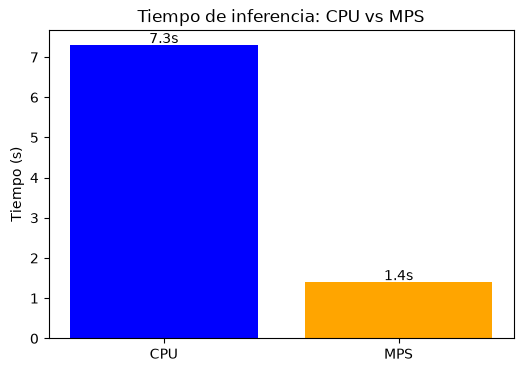

In [14]:
import matplotlib.pyplot as plt

# Tiempos medidos
t_cpu = 7.3
t_mps = 1.4

speedup = t_cpu / t_mps
efficiency = (1 - t_mps / t_cpu) * 100

print(f"Speedup MPS vs CPU: {speedup:.2f}x")
print(f"Reducción de tiempo: {efficiency:.1f}%")

# Gráfica simple
dispositivos = ["CPU", "MPS"]
tiempos = [t_cpu, t_mps]

plt.figure(figsize=(6, 4))
plt.bar(dispositivos, tiempos, color=["blue", "orange"])
plt.ylabel("Tiempo (s)")
plt.title("Tiempo de inferencia: CPU vs MPS")
for i, valor in enumerate(tiempos):
    plt.text(i, valor + 0.05, f"{valor:.1f}s", ha="center")
plt.show()


Ejercicio: hacer un pipeline de `text-generation`
---
---


### 4. pipeline("text-generation", model="distilgpt2")
Otra forma para la generación de texto:

```python
from transformers import pipeline
generator = pipeline("text-generation", model="distilgpt2")
generator(
    "In this course, we will teach you how to",
    max_length=30,
    num_return_sequences=2,
)
```
- Tarea: igual que el anterior, pero con un modelo mucho más pequeño.

- Modelo: distilgpt2 (versión distilada de GPT‑2).

- Entrada: prompt y parámetros de generación.

- Salida: dos continuaciones distintas (num_return_sequences=2), cada una como dict con generated_text.

Diferencia clave: SmolLM3‑3B es más grande y potente; DistilGPT2 es ligero y rápido, útil para demos y entornos con pocos recursos.



In [15]:
from transformers import pipeline
generator = pipeline("text-generation", model="distilgpt2")
generator(
    "In this course, we will teach you how to",
    max_length=30,
    num_return_sequences=3,
)

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 4539.48it/s]
[transformers] Passing `generation_config` toget

[{'generated_text': 'In this course, we will teach you how to perform and how to perform a traditional dance and dance in a simple and simple way. I will give you the basics of dance and dance technique.\n\nIn this course you will learn how to perform and how to perform a traditional dance and dance in a simple and simple way. I will give you the basics of dance and dance technique.\nThe main lesson is how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how to perform and how t

Ejercicio propuesto: Ejecuta nuevamente el generador con distilgpt2, pero ahora limita explícitamente la longitud de la respuesta usando max_new_tokens (por ejemplo 40) en lugar de max_length. Vuelve a imprimir el resultado con print(outputs[0]["generated_text"]) y comenta si disminuyó la repetición y el número de líneas en blanco.

### 5. `pipeline("fill-mask")`
Celda de “mask filling”:

```python
from transformers import pipeline
unmasker = pipeline("fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)
```
- Tarea: predicción de la palabra que falta en una secuencia (masked language modeling).

- Modelo por defecto: distilbert/distilroberta-base (RoBERTa distilado).

Entrada:

- Texto con un token especial de máscara (<mask> o el que use el modelo).

- top_k: cuántas alternativas devolver.

- Salida: lista de predicciones; cada dict tiene score, token, token_str y sequence con el texto completado.

Ejemplo:

In [16]:
from transformers import pipeline

unmasker = pipeline("fill-mask")
unmasker("This course will teach you all about <mask> models.", top_k=2)

[transformers] No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8.
Using a pipeline without specifying a model name and revision in production is not recommended.
C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--distilbert--distilroberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.m

[{'score': 0.1961975395679474,
  'token': 30412,
  'token_str': ' mathematical',
  'sequence': 'This course will teach you all about mathematical models.'},
 {'score': 0.04052716866135597,
  'token': 38163,
  'token_str': ' computational',
  'sequence': 'This course will teach you all about computational models.'}]

### 7. pipeline("document-question-answering") (con error)
Celda que intenta QA sobre documento:

```py
from transformers import pipeline
question_answerer = pipeline("document-question-answering")
question_answerer(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn"
)
```
- Tarea esperada: responder preguntas sobre documentos tipo PDF/imagen.

- Modelo por defecto: impira/layoutlm-document-qa.

- Error: TypeError: ... missing 1 required positional argument: 'image'.

Explicación:

Este pipeline está diseñado para QA sobre documentos visuales (imágenes), por lo que espera un argumento image (p.ej. un PIL.Image o path a imagen) además de question.

El ejemplo pasa solo question y context como si fuera QA de texto, por eso falla.

Para QA sobre texto plano deberías usar pipeline("question-answering"), no "document-question-answering".

In [20]:
# Para preguntas y respuestas basadas en texto, usamos el pipeline `question-answering`
# El pipeline `document-question-answering` requiere una imagen (PDF o foto) y no funciona sólo con texto.
from transformers import pipeline
question_answerer = pipeline("document-question-answering")
result = question_answerer(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn"
)
print(result)

[transformers] No model was supplied, defaulted to impira/layoutlm-document-qa and revision beed3c4.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 205/205 [00:00<00:00, 4181.66it/s]


TypeError: DocumentQuestionAnsweringPipeline.__call__() missing 1 required positional argument: 'image'

#### 8. pipeline("summarization", model="t5-small") (con error en tu versión)

```py
from transformers import pipeline
summarizer = pipeline("summarization", model="t5-small")
summarizer(long_text)
```
Tarea: resumir textos largos.

Modelo esperado: t5-small, que soporta tareas seq2seq (traducción, resumen, etc.).

Error: KeyError: "Unknown task summarization, available tasks are [...]".

Esto pasa porque estás usando una versión de transformers donde el task "summarization" aún no está registrado en pipeline (o lo está bajo otro nombre, normalmente "text2text-generation").

Solución típica:

python
summarizer = pipeline("text2text-generation", model="t5-small")

In [18]:
from transformers import pipeline

summarizer = pipeline("summarization", model="t5-small")
summarizer(
    """
    America has changed dramatically during recent years. Not only has the number of
    graduates in traditional engineering disciplines such as mechanical, civil,
    electrical, chemical, and aeronautical engineering declined, but in most of
    the premier American universities engineering curricula now concentrate on
    and encourage largely the study of engineering science. As a result, there
    are declining offerings in engineering subjects dealing with infrastructure,
    the environment, and related issues, and greater concentration on high
    technology subjects, largely supporting increasingly complex scientific
    developments. While the latter is important, it should not be at the expense
    of more traditional engineering.

    Rapidly developing economies such as China and India, as well as other
    industrial countries in Europe and Asia, continue to encourage and advance
    the teaching of engineering. Both China and India, respectively, graduate
    six and eight times as many traditional engineers as does the United States.
    Other industrial countries at minimum maintain their output, while America
    suffers an increasingly serious decline in the number of engineering graduates
    and a lack of well-educated engineers.
"""
)

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

#### 9. pipeline("translation", model="Helsinki-NLP/opus-mt-fr-en") (con error)

```py
from transformers import pipeline
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-fr-en")
translator("Ce cours est produit par Hugging Face.")
```

Tarea: traducir texto del francés al inglés.

Modelo: Helsinki-NLP/opus-mt-fr-en.

Error: KeyError: "Unknown task translation, available tasks are [...]".

De nuevo, tu versión de transformers no tiene registrado el alias "translation" como tarea de pipeline; en versiones recientes se usa "translation_xx_to_yy" o "text2text-generation" para muchos modelos de traducción.

In [19]:
from transformers import pipeline
translator = pipeline("translation", model="Helsinki-NLP/opus-mt-fr-en")
translator("Ce cours est produit par Hugging Face.")

C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ADMIN\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-fr-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


KeyError: "Unknown task translation, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

#### 10. pipeline("ner", aggregation_strategy="simple")

``` py
from transformers import pipeline
ner = pipeline("ner", aggregation_strategy="simple")
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")
```
- Tarea: reconocimiento de entidades nombradas (NER) token a token, agregando tokens contiguos en una misma entidad.

- Modelo por defecto: dbmdz/bert-large-cased-finetuned-conll03-english.

Parámetro clave:

- aggregation_strategy="simple": combina tokens contiguos con la misma etiqueta en una entidad mayor con entity_group, start, end.

- Salida: lista de entidades con entity_group (PER, ORG, LOC), score, word, start, end.



In [ ]:
from transformers import pipeline
ner = pipeline("ner", aggregation_strategy="simple")
ner("My name is Sylvain and I work at Hugging Face in Brooklyn.")

In [ ]:
from transformers import pipeline
ner = pipeline("ner", aggregation_strategy="simple")
ner("Mi nombre es jorge blanco y vivo en bogota y trabajo para una empresa BSG Institute.")

In [ ]:
from transformers import pipeline

ner_es = pipeline(
    "ner",
    model="mrm8488/bert-spanish-cased-finetuned-ner",
    tokenizer=("mrm8488/bert-spanish-cased-finetuned-ner", {"use_fast": False}),
    aggregation_strategy="simple",
)

texto = "Mi nombre es Jorge Blanco y vivo en Bogotá y trabajo para una empresa BSG Institute."
ner_es(texto)

# Tabla resumen de pipelines de Transformers

| Tarea principal | `pipeline(...)` | Modelo por defecto (si no se indica) | Uso típico en clase | Riesgos de seguridad / cumplimiento |
| --- | --- | --- | --- | --- |
| Análisis de sentimiento | `"sentiment-analysis"` | `distilbert/distilbert-base-uncased-finetuned-sst-2-english`  | Clasificar textos como positivos o negativos, por ejemplo reseñas, comentarios o publicaciones cortas.  | Puede procesar textos con datos personales o sensibles; no conviene guardar textos originales sin anonimización.  |
| Clasificación zero-shot | `"zero-shot-classification"` | `facebook/bart-large-mnli`  | Clasificar textos en categorías definidas por el usuario sin reentrenar el modelo.  | Si el texto contiene PII o datos sensibles, la clasificación puede exponer atributos delicados como ideología, salud o perfil personal.  |
| Generación de texto | `"text-generation"` | Depende del modelo indicado; en el cuaderno se usa `HuggingFaceTB/SmolLM3-3B` y también `distilgpt2`.  | Completar prompts, redactar ejemplos, crear explicaciones o generar texto libre.  | Puede alucinar, inventar hechos o producir contenido inapropiado; no debe usarse con datos sensibles ni para decisiones críticas sin revisión humana.  |
| Rellenar máscara | `"fill-mask"` | `distilbert/distilroberta-base`  | Mostrar cómo el modelo predice la palabra faltante en una frase con `<mask>`.  | Puede reflejar sesgos del lenguaje o sugerir términos estereotipados; útil para enseñar sesgo, pero no para automatizar decisiones sensibles.  |
| Reconocimiento de entidades nombradas | `"ner", aggregation_strategy="simple"` | `dbmdz/bert-large-cased-finetuned-conll03-english`  | Detectar nombres de personas, organizaciones y lugares en texto.  | Muy importante para anonimización, cumplimiento y seguridad; un falso negativo puede dejar PII sin detectar, y un falso positivo puede ocultar información no sensible.  |
| Preguntas sobre documentos | `"document-question-answering"` | `impira/layoutlm-document-qa`  | Responder preguntas sobre documentos visuales, como imágenes o PDFs escaneados.  | Los documentos pueden contener datos financieros, legales o médicos; requiere controles estrictos de acceso, almacenamiento y enmascaramiento.  |
| Resumen de texto | `"summarization"` | En tu versión del entorno esta tarea da error y no aparece registrada correctamente.  | En teoría, resumir textos largos para obtener una versión más corta.  | El resumen puede seguir exponiendo PII o distorsionar el contenido original; también sirve para discutir problemas de versiones de librerías.  |
| Traducción | `"translation"` | En tu versión del entorno esta tarea da error; en el ejemplo se usa `Helsinki-NLP/opus-mt-fr-en`.  | Traducir texto entre idiomas en ejemplos de NLP multilingüe.  | Traducir no elimina información sensible; la PII sigue existiendo aunque cambie de idioma.  |

© *2026 Jorge Blanco - BSG Institute.* All rights reserved.

*This Notebook is provided for educational and non‑commercial purposes only.
Any redistribution, modification, or commercial use requires prior written permission.*